### monomer trajectories

- system: TPP3 protein monomer
- thermostat: Nose-Hoover
- box-type: Cubic

In [1]:
# Import modules

import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import Boltzmann
from pathlib import Path
from itertools import count
p = Path('.')
from Dfit import *
from matplotlib.ticker import MultipleLocator
import pandas as pd
from scipy.stats import kde
from sklearn.neighbors import KernelDensity

/home/pallab/Softwares/anaconda3/envs/MDAna/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


# Analysis

Please scroll-down to the Results section for manuscript figures

In [2]:
# List of plot colors

COLORs2 = ['navy','crimson']
COLORs4 = ['navy','dodgerblue','orange','crimson']

# To format plots into publication quality figures

def FormatPlot(ax):
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(2)
    ax.xaxis.set_tick_params(width=2,length=8,direction='in',labelsize=12)
    ax.yaxis.set_tick_params(width=2,length=8,direction='in',labelsize=12)
    ax.xaxis.set_tick_params(which='minor',width=2,length=4,direction='in')
    ax.yaxis.set_tick_params(which='minor',width=2,length=4,direction='in')
    # 1. Get the tick labels for the X-axis and set their font weight
    for label in ax.get_xticklabels():
        label.set_fontweight('bold')
    
    # 2. Get the tick labels for the Y-axis and set their font weight
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')
    ax.grid(which='major',color='silver',linestyle='dashed')
    ax.grid(which='minor',color='silver',linestyle='dotted',alpha=0.5)

In [3]:
def getDiffCo(fileName,TC=50):
    res = Dfit.Dcov(m=20,fz=fileName,tmin=1,tmax=100,nseg=150,dt=5)
    res.run_Dfit()
    res.analysis(tc=TC)
    return res

In [11]:
def PLOT_Dfitax(Dfit_Objs,ax,COLOR,YLIM,MAJOR,MINOR,yshow=True,xshow=True,tc=400):
    tmin = Dfit_Objs[0].tmin
    tmax = Dfit_Objs[0].tmax
    dt = Dfit_Objs[0].dt
    
    meanD_p = np.array([Obj.D for Obj in Dfit_Objs]).mean(axis=0)#*100
    stdvD_p = np.array([Obj.Dstd for Obj in Dfit_Objs]).mean(axis=0)#*100
    empsD_p = np.array([Obj.Dempstd for Obj in Dfit_Objs]).mean(axis=0)#*100
    
    xs = np.arange(tmin*dt,(tmax+1)*dt,dt)/1000
    #print(xs)
    ax.plot(xs,meanD_p,color=COLOR,label=r'$D$')
    ax.plot(xs,meanD_p-stdvD_p,color='black',linestyle='dotted', label=r'$\delta \overline{D}^\mathrm{predicted}$')
    ax.plot(xs,meanD_p+stdvD_p,color='black',linestyle='dotted')
    ax.fill_between(xs,meanD_p-empsD_p,meanD_p+empsD_p,color=COLOR,alpha=0.5, label = r'$\delta \overline{D}^\mathrm{empirical}$')
    ax.axvline(tc,color='k',linestyle='dashed')
    ax.xaxis.set_minor_locator(MultipleLocator(50))
    ax.yaxis.set_minor_locator(MultipleLocator(MINOR))
    ax.yaxis.set_major_locator(MultipleLocator(MAJOR))
    if yshow:
        ax.set_ylabel(r'$\bf{D_{P}\;(nm^{2}\,ps^{-1})}$',fontsize=14)
    if xshow:
        ax.set_xlabel(r'$\bf{\tau_{lag}\;(ns)}$', fontsize=14)
    ax.set(xlim=(tmin*dt/1000,tmax*dt/1000))
    ax.ticklabel_format(style='scientific',scilimits=(-3,4))
    ax.legend(ncol=3,fontsize=12)
    #ax.set_xlim(0,250)
    ax.set_ylim(*list(YLIM))
    ax.ticklabel_format(axis='y', style='sci', scilimits=(-2,-4))
    FormatPlot(ax)
    if yshow==False:
        ax.tick_params(axis='y', labelleft=False)
    fig.tight_layout(h_pad=0.1)
    return meanD_p

In [13]:
from matplotlib.ticker import LogLocator, LogFormatter

def PLOT_Dfitax_Logscale(Dfit_Objs,ax,COLOR,YLIM,MAJOR,MINOR,label,yshow=True,xshow=True,tc=400,lstyle='solid'):
    tmin = Dfit_Objs[0].tmin
    tmax = Dfit_Objs[0].tmax
    dt = Dfit_Objs[0].dt
    
    meanD_p = np.array([Obj.D for Obj in Dfit_Objs]).mean(axis=0)#*100
    stdvD_p = np.array([Obj.Dstd for Obj in Dfit_Objs]).mean(axis=0)#*100
    empsD_p = np.array([Obj.Dempstd for Obj in Dfit_Objs]).mean(axis=0)#*100
    
    xs = np.arange(tmin*dt,(tmax+1)*dt,dt)/1000
    ax.plot(xs,meanD_p,color=COLOR,label=label,linestyle=lstyle)
    ax.set_yscale('log',base=10)
    ax.axvline(tc/1000,color='k',linestyle='dashed')
    if yshow:
        ax.set_ylabel(r'$\bf{D_{P}\;(nm^{2}ps^{-1})}$',fontsize=14)
    if xshow:
        ax.set_xlabel(r'$\bf{\tau_{lag}\;(ns)}$', fontsize=14)
    
    ax.set(xlim=(tmin*dt/1000,tmax*dt/1000))
    FormatPlot(ax)
    fig.tight_layout(h_pad=0.1)
    return meanD_p

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.ticker import MultipleLocator

def plot_xy_trajectory(ax, file_path: str, start_time: int, xlim: list, ylim: list, 
                       radii: list, major: float, minor: float, circle_edge_color: str = 'darkslateblue', rc_ref: int = None, rc_ref_color: str = 'k'):
    """
    Plots the XY cross-section of a 3D trajectory onto a given Matplotlib Axes object.

    Args:
        ax (plt.Axes): The Matplotlib Axes object to plot on.
        file_path (str): The path to the trajectory data file (N x 3 NumPy array).
        start_time (int): The starting frame number for the trajectory segment to be plotted.
        xlim (list): A list or tuple of two numbers for the x-axis limits.
        ylim (list): A list or tuple of two numbers for the y-axis limits.
        radii (list): A list of float values for the radii of additional circles to plot.
        circle_edge_color (str): The color for the circumference of the circles.
        
    Returns:
        LineCollection: The line collection object of the trajectory, which can be used to create a colorbar.
    """
    # --- Data Loading and Validation ---
    try:
        trajectory = np.loadtxt(file_path)
    except FileNotFoundError:
        print(f"Error: The file '{file_path}' was not found.")
        return None

    n_frames = trajectory.shape[0]
    segment_length = 500
    if start_time + segment_length > n_frames:
        print(f"Error: The trajectory is too short. It only has {n_frames} frames.")
        return None

    # --- Compute MSD and Critical Radius ---
    trajectory_centered = trajectory - trajectory[start_time]
    squared_displacements = np.sum((trajectory[start_time + segment_length:, :] - trajectory[start_time:-segment_length, :])**2, axis=1)
    msd = np.mean(squared_displacements)
    std = np.std(squared_displacements)
    rc = np.sqrt(msd) + np.sqrt(std)
    
    #print(f"Mean Squared Displacement (MSD): {msd:.2f}")
    #print(f"Critical radius (rc): {rc:.2f}")
    
    # --- Prepare XY Data ---
    traj_segment = trajectory_centered[start_time : start_time + segment_length, :]
    end_point = traj_segment[-1, :]
    
    xy_traj = np.column_stack((traj_segment[:, 0], traj_segment[:, 1]))
    xy_center = np.array([0, 0]) # The trajectory is centered at the origin
    xy_end = np.array([end_point[0], end_point[1]])

    # --- Plot Trajectory Line ---
    t = np.arange(xy_traj.shape[0])
    points = xy_traj.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    cmap = plt.get_cmap('summer_r')
    lc = LineCollection(segments, cmap=cmap, linewidth=3)
    lc.set_array(t[:-1])
    line = ax.add_collection(lc)

    # --- Plot Circles ---
    # Plot the original critical radius circle
    if rc_ref is not None:
        rc_circle = plt.Circle(xy_center, rc, facecolor='none', edgecolor=circle_edge_color, 
                         linewidth=2, label=f'Critical Radius ($r_c$={rc:.1f})', zorder=1)
    else:
        rc_circle = plt.Circle(xy_center, rc, facecolor='none', edgecolor=circle_edge_color, 
                         linewidth=2, linestyle='--', label=f'Critical Radius ($r_c$={rc:.1f})', zorder=1)
    ax.add_patch(rc_circle)

    if rc_ref is not None:
        rc_circle_ref = plt.Circle(xy_center, radii[rc_ref], facecolor='none', edgecolor=rc_ref_color, 
                         linewidth=2, linestyle='--', label=f'Critical Radius ($r_c$={rc:.1f})', zorder=1)
        ax.add_patch(rc_circle_ref)

    # Plot the 4 additional circles from the input list
    #for i,r in enumerate(radii):
    #    circle = plt.Circle(xy_center, r, facecolor='none', edgecolor=colors[i], 
                            #linewidth=1.5, zorder=0)
    #    ax.add_patch(circle)

    # --- Plot End Point and Set Labels ---
    end_color = cmap(1.0)
    ax.scatter(xy_end[0], xy_end[1], color=end_color, marker='o', s=120, 
               label='End Point', zorder=3, edgecolors='black')
    
    #ax.set_title("XY-plane View", fontsize=16)
    #ax.set_xlabel("X", fontsize=12)
    #ax.set_ylabel("Y", fontsize=12)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, linestyle='--', alpha=0.5)
    #ax.legend(loc='best', fontsize=10)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)

    ax.xaxis.set_major_locator(MultipleLocator(major))
    ax.yaxis.set_major_locator(MultipleLocator(major))
    ax.xaxis.set_minor_locator(MultipleLocator(minor))
    ax.yaxis.set_minor_locator(MultipleLocator(minor))
    FormatPlot(ax)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.set_aspect('equal')
    
    return line # Return the line object so a colorbar can be made outside

Analyzing single trajectory.
N = 1000000
ndim = 3
Warning, too many segments chosen, falling back to nseg = 100


100% (100 of 100) |######################| Elapsed Time: 0:00:29 Time:  0:00:290003


Analyzing single trajectory.
N = 1000000
ndim = 3
Warning, too many segments chosen, falling back to nseg = 100


100% (100 of 100) |######################| Elapsed Time: 0:00:29 Time:  0:00:290003


Finite-size corrected diffusion coefficient D_t for timestep 400 ps: 6.522e-07 nm^2/ps with standard dev. 1.802e-08 nm^2/ps
Finite-size corrected diffusion coefficient D_t for timestep 400 ps: 6.508e-07 nm^2/ps with standard dev. 1.79e-08 nm^2/ps


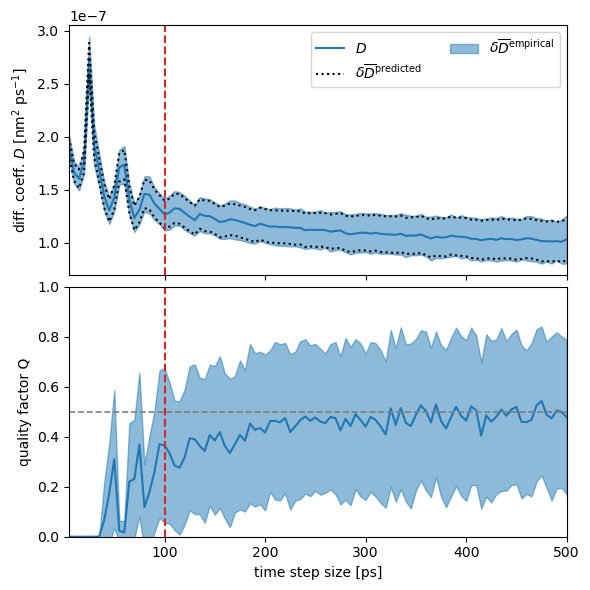

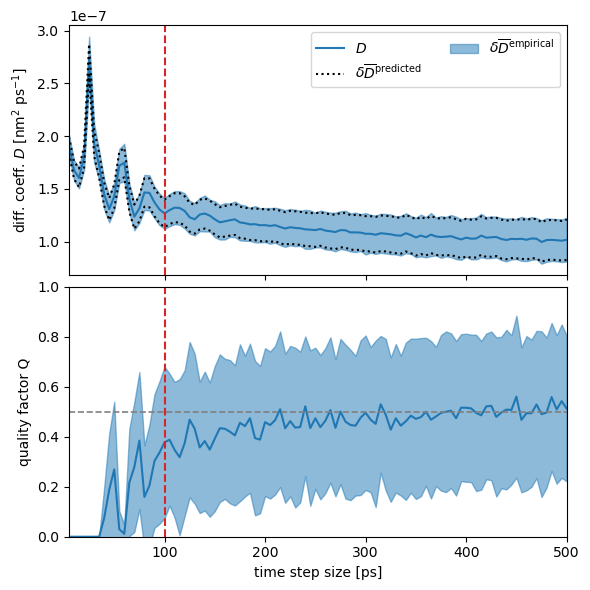

In [5]:
mono1_220K = "tpp3-220K-cubic-mono1.dat"    # monomer1 center-of-mass (COM), 220K, cubic box
mono2_220K = "tpp3-220K-cubic-mono2.dat"    # monomer2 center-of-mass (COM), 220K, cubic box

Temp = 220 # Kelvin
Visco = 105.448544e-3 # Pa.S
Boxsize_220K = 79.265976e-1 # nm

# Generalized least square fitting
D1m1_220K = getDiffCo(mono1_220K,TC=100)
D1m2_220K = getDiffCo(mono2_220K,TC=100)

# Corrections for finite-size effect
D1m1_220K.finite_size_correction(T=Temp, eta=Visco, L=Boxsize_220K, tc=400)
D1m2_220K.finite_size_correction(T=Temp, eta=Visco, L=Boxsize_220K, tc=400)

Analyzing single trajectory.
N = 1000000
ndim = 3
Warning, too many segments chosen, falling back to nseg = 100


100% (100 of 100) |######################| Elapsed Time: 0:00:32 Time:  0:00:320003


Analyzing single trajectory.
N = 1000000
ndim = 3
Warning, too many segments chosen, falling back to nseg = 100


100% (100 of 100) |######################| Elapsed Time: 0:00:30 Time:  0:00:300002


Finite-size corrected diffusion coefficient D_t for timestep 400 ps: 6.944e-07 nm^2/ps with standard dev. 2.456e-08 nm^2/ps
Finite-size corrected diffusion coefficient D_t for timestep 400 ps: 7.012e-07 nm^2/ps with standard dev. 2.553e-08 nm^2/ps


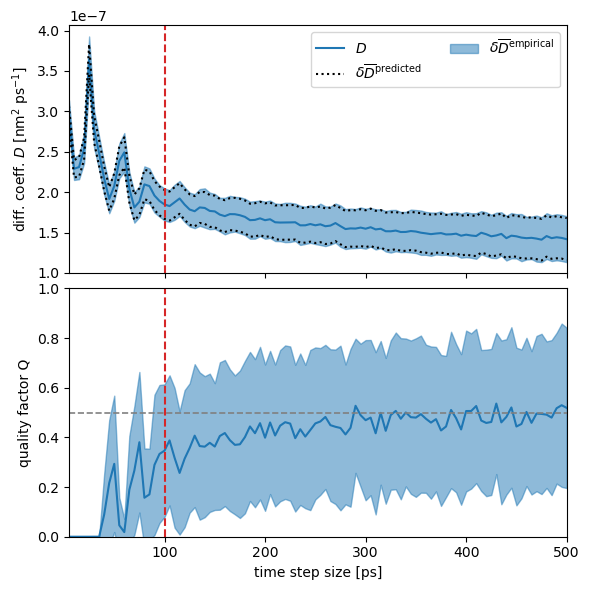

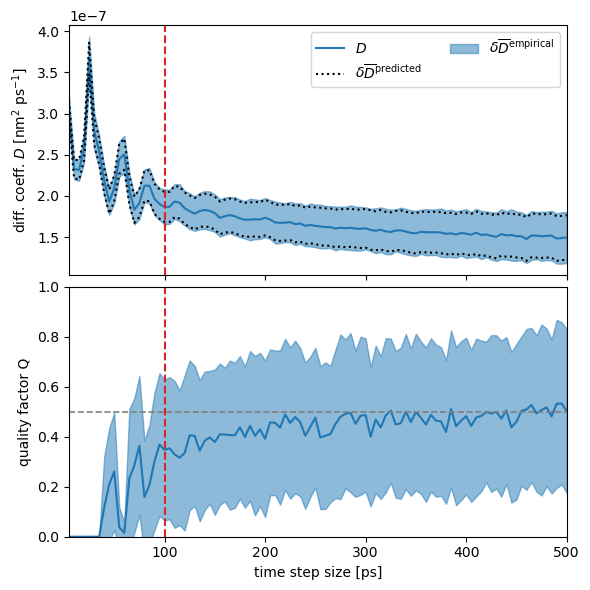

In [7]:
mono1_p310s220 = "tpp3-p310s220-cubic-mono1.dat"    # monomer1 center-of-mass (COM), p310s220, cubic box
mono2_p310s220 = "tpp3-p310s220-cubic-mono2.dat"    # monomer2 center-of-mass (COM), p310s220, cubic box

Temp = 220 # Kelvin
Visco = 105.448544e-3 # Pa.S
Boxsize_p310s220 = 79.26946e-1 # nm

# Generalized least square fitting
D1m1_p310s220 = getDiffCo(mono1_p310s220,TC=100)
D1m2_p310s220 = getDiffCo(mono2_p310s220,TC=100)

# Corrections for finite-size effect
D1m1_p310s220.finite_size_correction(T=Temp, eta=Visco, L=Boxsize_p310s220, tc=400)
D1m2_p310s220.finite_size_correction(T=Temp, eta=Visco, L=Boxsize_p310s220, tc=400)

Analyzing single trajectory.
N = 1000000
ndim = 3
Warning, too many segments chosen, falling back to nseg = 100


100% (100 of 100) |######################| Elapsed Time: 0:00:31 Time:  0:00:310003


Analyzing single trajectory.
N = 1000000
ndim = 3
Warning, too many segments chosen, falling back to nseg = 100


100% (100 of 100) |######################| Elapsed Time: 0:00:31 Time:  0:00:310003


Finite-size corrected diffusion coefficient D_t for timestep 400 ps: 0.0001406 nm^2/ps with standard dev. 2.014e-06 nm^2/ps
Finite-size corrected diffusion coefficient D_t for timestep 400 ps: 0.0001408 nm^2/ps with standard dev. 2.041e-06 nm^2/ps


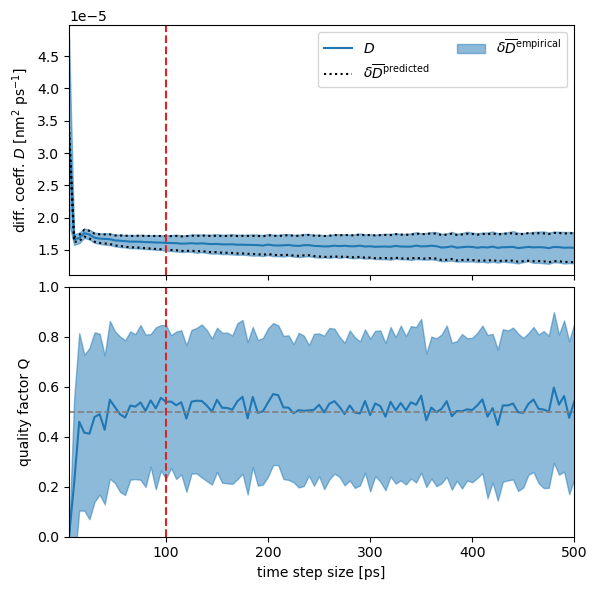

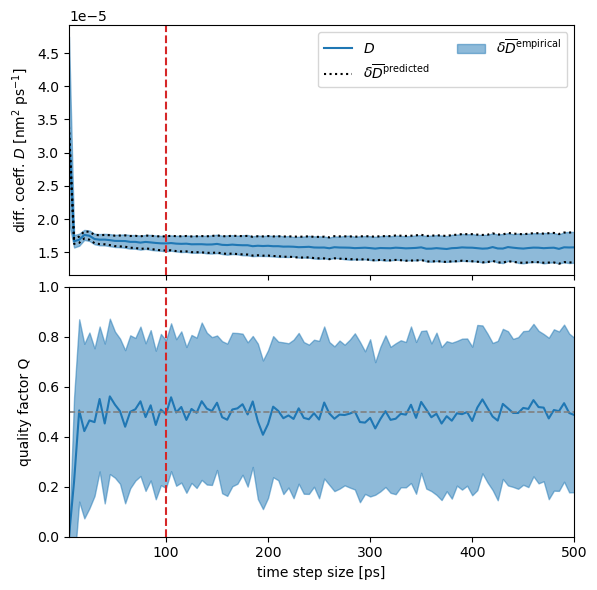

In [8]:
mono1_p220s310 = "tpp3-p220s310-cubic-mono1.dat"    # monomer1 center-of-mass (COM), p220s310, cubic box
mono2_p220s310 = "tpp3-p220s310-cubic-mono2.dat"    # monomer2 center-of-mass (COM), p220s310, cubic box

Temp = 310 # Kelvin
Visco = 0.655052e-3 # Pa.S
Boxsize_p220s310 = 78.621056e-1 # nm

# Generalized least square fitting
D1m1_p220s310 = getDiffCo(mono1_p220s310,TC=100)
D1m2_p220s310 = getDiffCo(mono2_p220s310,TC=100)

# Corrections for finite-size effect
D1m1_p220s310.finite_size_correction(T=Temp, eta=Visco, L=Boxsize_p220s310, tc=400)
D1m2_p220s310.finite_size_correction(T=Temp, eta=Visco, L=Boxsize_p220s310, tc=400)

Analyzing single trajectory.
N = 1000000
ndim = 3
Warning, too many segments chosen, falling back to nseg = 100


100% (100 of 100) |######################| Elapsed Time: 0:00:30 Time:  0:00:300003


Analyzing single trajectory.
N = 1000000
ndim = 3
Warning, too many segments chosen, falling back to nseg = 100


100% (100 of 100) |######################| Elapsed Time: 0:00:30 Time:  0:00:300002


Finite-size corrected diffusion coefficient D_t for timestep 400 ps: 0.0001456 nm^2/ps with standard dev. 2.634e-06 nm^2/ps
Finite-size corrected diffusion coefficient D_t for timestep 400 ps: 0.0001455 nm^2/ps with standard dev. 2.639e-06 nm^2/ps


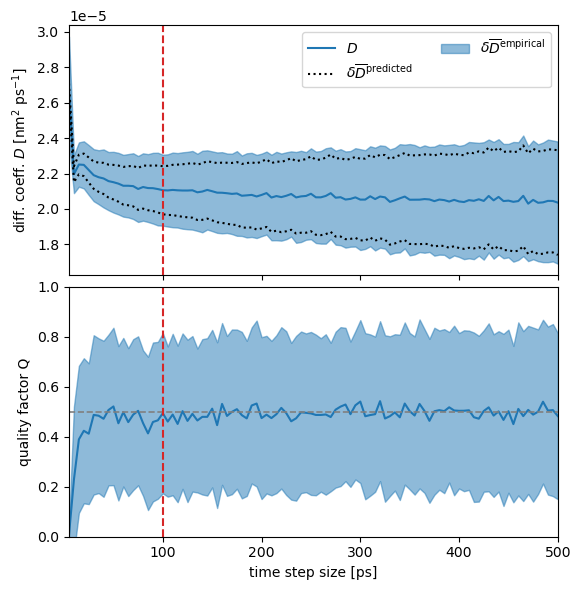

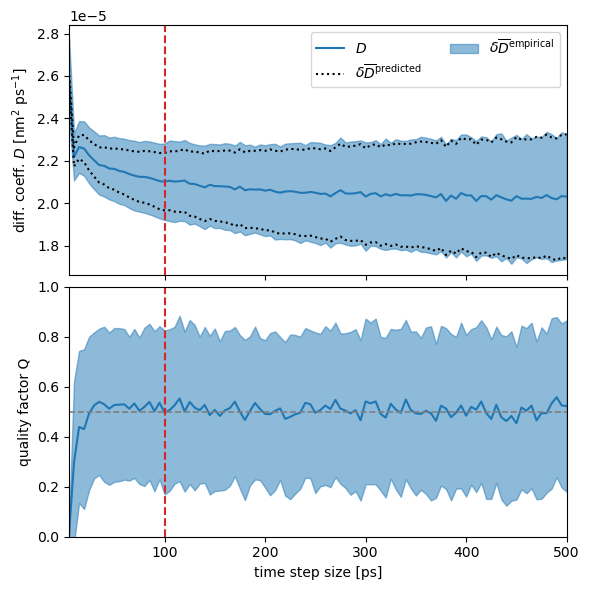

In [9]:
mono1_310K = "tpp3-310K-cubic-mono1.dat"    # monomer1 center-of-mass (COM), 310K, cubic box
mono2_310K = "tpp3-310K-cubic-mono2.dat"    # monomer2 center-of-mass (COM), 310K, cubic box

Temp = 310 # Kelvin
Visco = 0.655052e-3 # Pa.S
Boxsize_310K = 78.579185e-1 # nm

# Generalized least square fitting
D1m1_310K = getDiffCo(mono1_310K,TC=100)
D1m2_310K = getDiffCo(mono2_310K,TC=100)

# Corrections for finite-size effect
D1m1_310K.finite_size_correction(T=Temp, eta=Visco, L=Boxsize_310K, tc=400)
D1m2_310K.finite_size_correction(T=Temp, eta=Visco, L=Boxsize_310K, tc=400)

# Figures

## Fig S4

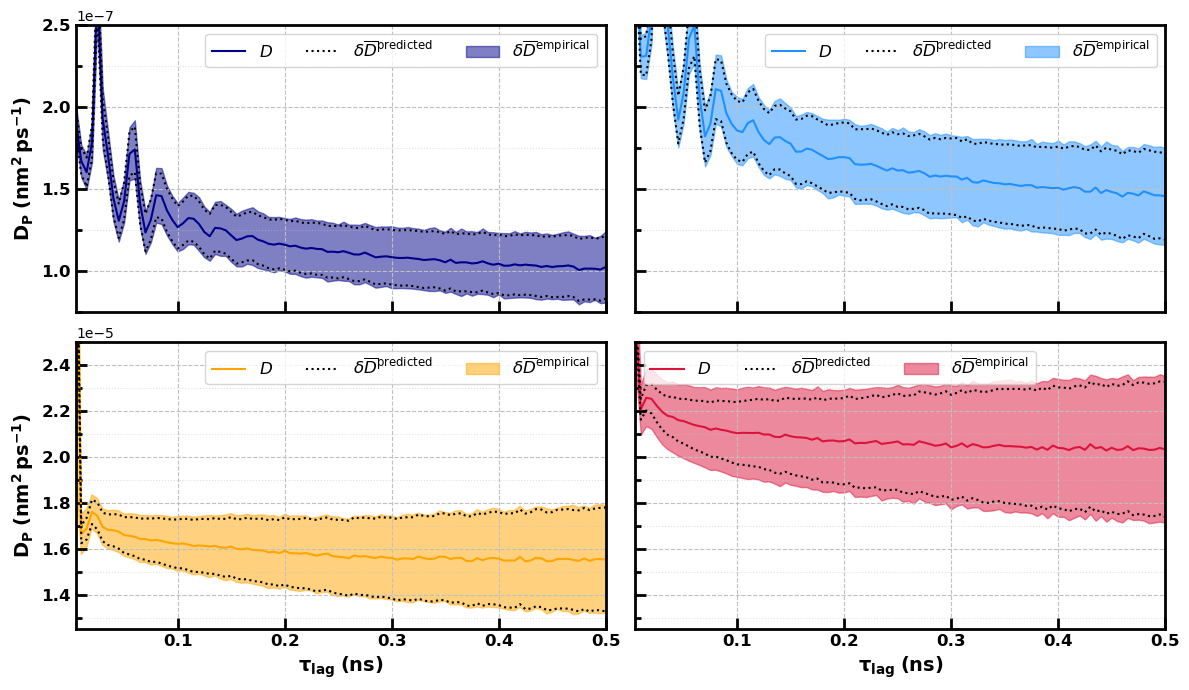

In [12]:
fig, ax = plt.subplots(2, 2, sharex=True, figsize=(12,7))
Dp_p220s220 = PLOT_Dfitax([D1m1_220K,D1m2_220K],ax[0,0],'darkblue',(0.75e-7,2.5e-7),0.5e-7,0.25e-7,xshow=False)
Dp_p310s220 = PLOT_Dfitax([D1m1_p310s220,D1m2_p310s220],ax[0,1],'dodgerblue',(0.75e-7,2.5e-7),0.5e-7,0.25e-7,False,xshow=False)
Dp_p220s310 = PLOT_Dfitax([D1m1_p220s310,D1m2_p220s310],ax[1,0],'orange',(1.25e-5,2.5e-5),0.2e-5,0.1e-5)
Dp_p310s310 = PLOT_Dfitax([D1m1_310K,D1m2_310K],ax[1,1],'crimson',(1.25e-5,2.5e-5),0.2e-5,0.1e-5,False)
fig.tight_layout()
#plt.savefig('GLS_D_protein.png')

## Fig 1C

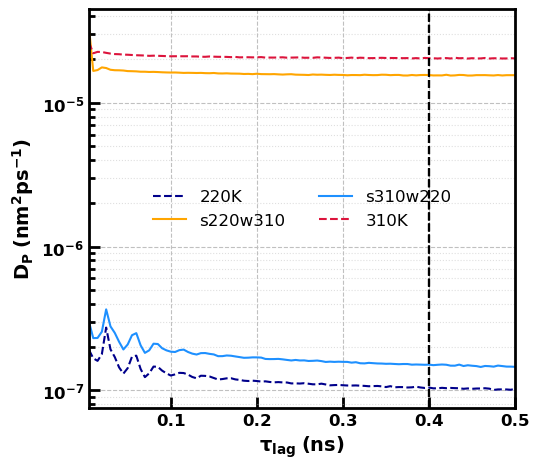

In [15]:
fig = plt.figure(figsize=(5.5,4.8))
ax = plt.gca()
Dp_p220s220 = PLOT_Dfitax_Logscale([D1m1_220K,D1m2_220K],ax,'darkblue',(0.75e-7,2.5e-7),0.5e-7,0.25e-7,label='220K',xshow=False,lstyle='dashed')
Dp_p310s220 = PLOT_Dfitax_Logscale([D1m1_p310s220,D1m2_p310s220],ax,'dodgerblue',(0.75e-7,2.5e-7),0.5e-7,0.25e-7,label='s310w220',yshow=False,xshow=False)
Dp_p220s310 = PLOT_Dfitax_Logscale([D1m1_p220s310,D1m2_p220s310],ax,'orange',(1.55e-5,2.5e-5),0.2e-5,0.1e-5,label='s220w310')
Dp_p310s310 = PLOT_Dfitax_Logscale([D1m1_310K,D1m2_310K],ax,'crimson',(1.55e-5,2.5e-5),0.2e-5,0.1e-5,label='310K',yshow=True,lstyle='dashed')

handles, labels = ax.get_legend_handles_labels()

order = [0, 2, 1, 3]
ax.legend([handles[i] for i in order], [labels[i] for i in order], 
          ncol=2, 
          loc='center', 
          frameon=False, 
          fontsize=12)

fig.tight_layout()
#plt.savefig('Diffusion_logy4.png',dpi=300)

## Fig S3

System: 220K, Characteristic radii (from Chi-sq distribution): 0.078

System: s310w220, Characteristic radii (from Chi-sq distribution): 0.091

System: 310K, Characteristic radii (from Chi-sq distribution): 0.977

System: s220w310, Characteristic radii (from Chi-sq distribution): 0.853



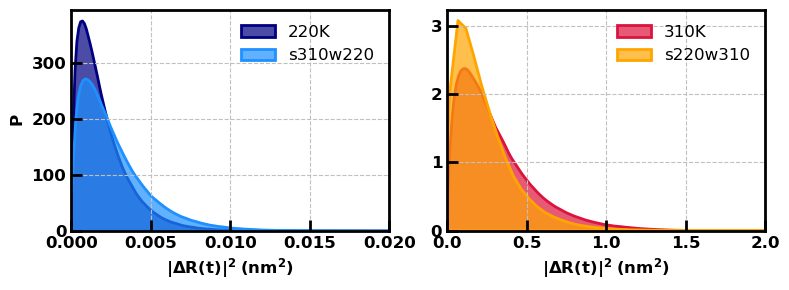

In [20]:
import seaborn as sns
from scipy.stats import chi2

def get_MSD(filepath,lagtime):
    trajectory = np.loadtxt(filepath)
    trajectory = trajectory - trajectory[0,:]
    MSDs = np.sum((trajectory[lagtime:, :] - trajectory[:-lagtime, :])**2, axis=1)
    return MSDs

colors = ['navy','dodgerblue','crimson','orange']
labels = ['220K','s310w220','310K','s220w310']
trajMono1 = ["tpp3-220K-cubic-mono1.dat","tpp3-p310s220-cubic-mono1.dat","tpp3-310K-cubic-mono1.dat","tpp3-p220s310-cubic-mono1.dat"]
trajMono2 = ["tpp3-220K-cubic-mono2.dat","tpp3-p310s220-cubic-mono2.dat","tpp3-310K-cubic-mono2.dat","tpp3-p220s310-cubic-mono2.dat"]

xlim = [0.02,2]

fig,axes = plt.subplots(1,2,figsize=(8,3))
for i,trajs in enumerate(zip(trajMono1,trajMono2)):
    traj1,traj2 = trajs
    j = i//2
    k = i%2
    color = colors[i]
    MSD1 = get_MSD(traj1,500)
    MSD2 = get_MSD(traj2,500)
    MSD = np.hstack((MSD1,MSD2))
    ax = axes[j]
    ax.set_xlim(0,xlim[j])
    sns.kdeplot(
    MSD,
    fill=True,
    alpha=0.7,
    color=color,
    lw=2,
    ax=ax,
    label=labels[i]
    )
    d = 3
    N = len(MSD)
    alpha = 0.05
    lower = np.sqrt(np.mean(MSD) / (d) * chi2.ppf(alpha/2, df=d))
    upper = np.sqrt(np.mean(MSD) / (d) * chi2.ppf(1-alpha/2, df=d))
    print(f"System: {labels[i]}, Characteristic radii (from Chi-sq distribution): {round(upper,3)}\n")
    FormatPlot(ax)
    if j==1:
        ax.set(ylabel=None)
    if j==0:
        ax.set_ylabel(r'$\bf{P}$',fontsize=12)
    ax.set_xlabel(r'$\bf{| \Delta R(t) |^2\;(nm^{2})}$',fontsize=12)
    ax.legend(frameon=False, fontsize=12)

plt.tight_layout()
#plt.savefig('ChiSq_SD1.png',dpi=300)

## Fig 1B

/tmp/ipykernel_4940/2984705541.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.set_ticklabels([0,0.1,0.2,0.3,0.4])


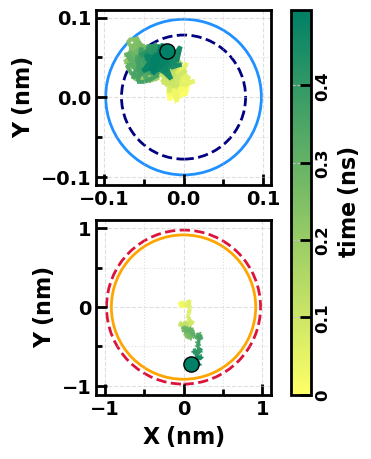

In [26]:
fig,axes = plt.subplots(2,1,figsize=(3.5,5))
trajList = ["tpp3-p310s220-cubic-mono1.dat","tpp3-p220s310-cubic-mono1.dat"]
start_times = [200,300]
start_times = [900,300]
xlims = [[-0.11,0.11],[-1.11,1.11]]
ylims = [[-0.11,0.11],[-1.11,1.11]]
majors = [0.1,1.0]
minors = [0.05,0.5]
colors = ['dodgerblue','orange']
rcrefs = [0,3]
rccols = ['navy','crimson']

chisq_radii = [0.078,0.091,0.853,0.977]

mappable = None   # <-- store returned LineCollection

for i in range(2):
    #j = i//2
    #k = i%2
    ax = axes[i] #[k]
    mappable = plot_xy_trajectory(ax,trajList[i], start_time=start_times[i], xlim=xlims[i],ylim=ylims[i],radii=chisq_radii,major=majors[i],minor=minors[i],circle_edge_color=colors[i],rc_ref=rcrefs[i],rc_ref_color=rccols[i])
    #print(mappable)
    if i==1:
        ax.set_xlabel(r'$\bf{X\;(nm)}$',fontsize=16)
    #if i==0:
    ax.set_ylabel(r'$\bf{Y\;(nm)}$',fontsize=16)

cbar = fig.colorbar(mappable, ax=axes, location='right', pad=0.075)
cbar.set_label(r"$\bf{time\;(ns)}$", fontsize=16)
cbar.set_ticklabels([0,0.1,0.2,0.3,0.4])
FormatPlot(cbar.ax)

# --- widen spines ---
for spine in cbar.ax.spines.values():
    spine.set_linewidth(2)

# --- rotate tick labels ---
for label in cbar.ax.get_yticklabels():
    label.set_rotation(90)
    label.set_va('center')
    #label.set_ha('center')

#plt.tight_layout()
#plt.savefig("RandomWalk6.png",dpi=300)